<a href="https://colab.research.google.com/github/rathore-rl1lmg1/Cooding-Playground/blob/main/minigrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import

In [1]:
!python3.11 -m pip install gymnasium numpy minigrid

/bin/bash: line 1: python3.11: command not found


In [2]:
!pip install gymnasium minigrid --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 14.5 MB/s eta 0:00:00


In [3]:
import gymnasium as gym
import numpy as np
import random
import sys
sys.path.append('/home/rathore/.local/lib/python3.11/site-packages/minigrid/minigrid_env.py')
import minigrid
import matplotlib.pyplot as plt

Taking Env

In [4]:
env = gym.make("MiniGrid-Empty-5x5-v0")
observation, info = env.reset()

State Action Size

In [5]:
state_size = env.unwrapped.width * env.unwrapped.height * 4

action_size = env.action_space.n
action_space = (0,1,2)
reward_plot = []
num_step =[]
epissode_plot = []

Initialization

In [6]:
#Initialize Q-Table
q_table = np.zeros((state_size , action_size))

#initialize variable for position and dir
x, y = env.unwrapped.agent_pos
d = env.unwrapped.agent_dir
state_size = (x,y,d)

#defining what data to replace in dtate space of q table
def get_state(env):
    x, y = env.unwrapped.agent_pos
    d = env.unwrapped.agent_dir
    return (y* env.unwrapped.width + x)*4 +d


Hyper Param

In [7]:
num_episodes = 5000
max_steps_per_episode = 100
sum = 0
learning_rate = 0.001
discount_rate = 0.99

exploration_rate = 1.0
min_exploration_rate = 0.1
max_exploration_rate = 1.0
exploration_rate_decay = 0.01

reward_all_episode = []

Q-Learning Algorithm

In [8]:
for episode in range(num_episodes):
    obs, _ = env.reset()
    state = get_state(env)
    reward_current_epi = 0
    epissode_plot.append(episode)

    for step in range(max_steps_per_episode):
        #exploration vs exploitation
        if random.uniform(0 , 1) < exploration_rate:  #exploration
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state , :]) #exploit

        obs , reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated


        #Q-table updete
        next_state = get_state(env)
        q_table[state , action] = q_table[state , action]*(1 - learning_rate) + learning_rate *(reward + discount_rate * np.max(q_table[next_state , :]) )

        state = next_state
        reward_current_epi += reward


        if done:
            break
        #exploration decay
        exploration_rate = min_exploration_rate +(max_exploration_rate - min_exploration_rate) * np.exp(-exploration_rate_decay * episode)


        reward_all_episode.append(reward_current_epi)
    reward_plot.append(reward_current_epi)
    num_step.append(step)



Result

avg reward per num epi
1000: 0.000
2000: 0.000
3000: 0.000
4000: 0.000
5000: 0.000

Final Q-table:
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00

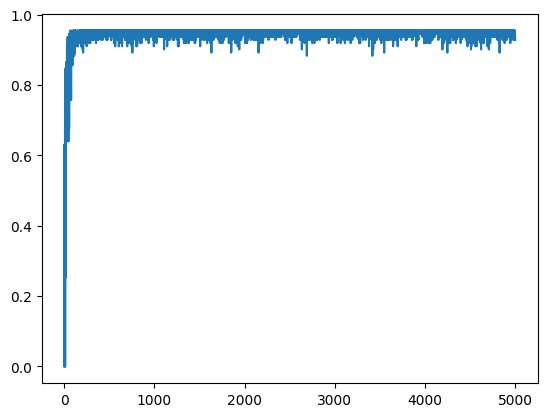

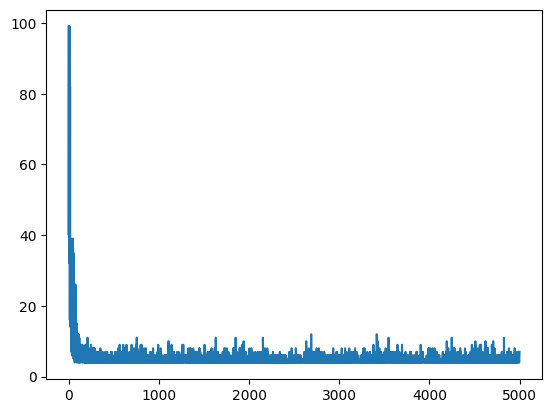

In [9]:
reward_per_num_epi = np.array_split(np.array(reward_all_episode), num_episodes // 1000)

print("avg reward per num epi")
count = 1000
for r in reward_per_num_epi:
    print(f"{count}: {np.mean(r):.3f}")
    count += 1000

#learned Q table

print("\nFinal Q-table:")
print(q_table)

#testing the agent
test_env = gym.make("MiniGrid-Empty-5x5-v0", render_mode="human")
obs, _ = test_env.reset()
state = get_state(test_env)
done = False
total_reward=0
while not done:
    action = np.argmax(q_table[state, :])
    _, reward, terminated, truncated, _ = test_env.step(action)
    state = get_state(test_env)
    done = terminated or truncated
    total_reward += reward
    test_env.render()
print(total_reward)
test_env.close()
plt.plot(epissode_plot ,reward_plot)
plt.show()
plt.plot(epissode_plot,num_step )
plt.show()

